# Update Featuring Distribution Binning Method using the Arize GraphQL API

Binning, also known as bucketing or discretization, is a data processing technique for reducing the cardinality of continuous and discrete data. Whether used in data pre-processing or post-processing, binning divides data from numeric features into a set of discrete intervals assigning each data point to its corresponding bin.

The applied binning strategy impacts directly the drift metric value, so it's important to select the most optimal method given the data characteristics.

Read the [full article on data binning](https://arize.com/blog-course/data-binning-production/) - a part of the broader [blog course on Drift](https://arize.com/blog-course/drift/).

### Step 1: Initialize the GraphQL Client using your developer API Key

In [1]:
!pip install gql[all]==3.5.3
from gql import Client, gql
from gql.transport.requests import RequestsHTTPTransport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.14.1 requires websockets<16.0.0,>=15.0.1, but you have websockets 11.0.3 which is incompatible.
dataproc-spark-connect 0.8.3 requires websockets>=14.0, but you have websockets 11.0.3 which is incompatible.
google-genai 1.38.0 requires websockets<15.1.0,>=13.0.0, but you have websockets 11.0.3 which is incompatible.
yfinan

### Get your API key
First - make sure you have developer permissions. If you are able to visit the [API explorer](https://app.arize.com/graphql), you have developer permissions, if not, please ask your Account Admin to provide you with access.

The API key can be retrieved from the [API explorer](https://app.arize.com/graphql) page. Click the button on the top right called "Get Your API Key." A modal will pop up with your key, copy that into the `API_KEY` constant below.

NOTE: this key is different than the SDK key used to send data to Arize.

In [2]:
from getpass import getpass
ARIZE_API_KEY = getpass("Arize API key: ")
ARIZE_SPACE_ID = input("Arize Space ID: ")
ARIZE_MODEL_NAME = input("Arize Model Name: ")


Arize API key: ··········
Arize Space ID: U3BhY2U6MTU1NTY6c3RPeQ==
Arize Model Name: classification_demo_fraud_model


In [7]:
ARIZE_APP_ENDPOINT = "https://app.arize.com/graphql"
# For EU: https://app.eu-west-1a.arize.com/graphql

In [8]:
# Select your transport with a defined url endpoint
transport = RequestsHTTPTransport(
    url=ARIZE_APP_ENDPOINT, headers={"x-api-key": ARIZE_API_KEY}
)

# Create a GraphQL client using the defined transport
client = Client(transport=transport, fetch_schema_from_transport=True)

## Define the GraphQL mutation

Install the [Arize GraphQL MCP Assistant]((https://github.com/Arize-ai/text-to-graphql-mcp)) to write the queries/mutations for you!

The mutation below will update the feature binning settings to the selected option.

In [9]:
update_binning_for_feature = gql(
  """
  mutation UpdateDimensionConfig($modelId: ID!, $dimensionName: String!, $binningOption: DimensionBinOption!) {
    updateDimensionConfig(input: {
      modelId: $modelId,
      dimensionName: $dimensionName,
      dimensionCategory: featureLabel,
      binOption: $binningOption
    }) {
      dimensionConfig {
        id
        modelId
        dimensionName
        dimensionCategory
        binOption
        numBins
        bins
      }
      model {
        id
        name
      }
    }
  }
  """
)

## Choose the binning approach


https://arize.com/blog-course/data-binning-production/

**Supported binning options:**

- **equalWidth** - The number of bins to use. All bins are equal width when using this option. The bin width is the delta between the min and max values divided by the number of bins. This binning strategy works best for uniform distributions.

- **custom** - The exact boundaries between bins. Integers, floats, inf and -inf are acceptable values. Example: [0, 1, 10, 10.5, inf] will create 4 bins, with the last bin going to infinity. This binning strategy works best when the data is not normally distributed or when you know exactly what bin to use.

- **medianCentered** - Bins are centered around the median. The bins are equal width except for the bins at the min and max of the range, which may be unequal width in order to include all data. This binning strategy works best for normal distributions.

- **discrete** - Each bin contains a single unique value. The number of bins is equal to the combined cardinality of the production and baseline datasets, limited to the top 1000 by volume values.

- **decile** - Each bin is a decile percentile. The bins are min, 10th percentile, 20th percentile, 30th percentile, 40th percentile, 50th percentile, 60th percentile, 70th percentile, 80th percentile, 90th percnetile, and max.

- **quantiles** - Each bin represents a custom percentile that the user inputs.

- **discreteTopN** - Each bin contains a single unique value. The number of bins is equal to n

## Define the variables

You will need to define the following the variables:
- **modelId** - should by copied from the UI model page
- **dimensionName** - name of the feature as displayed on the feature details page
- **binningOption** - one of the supported binning values above

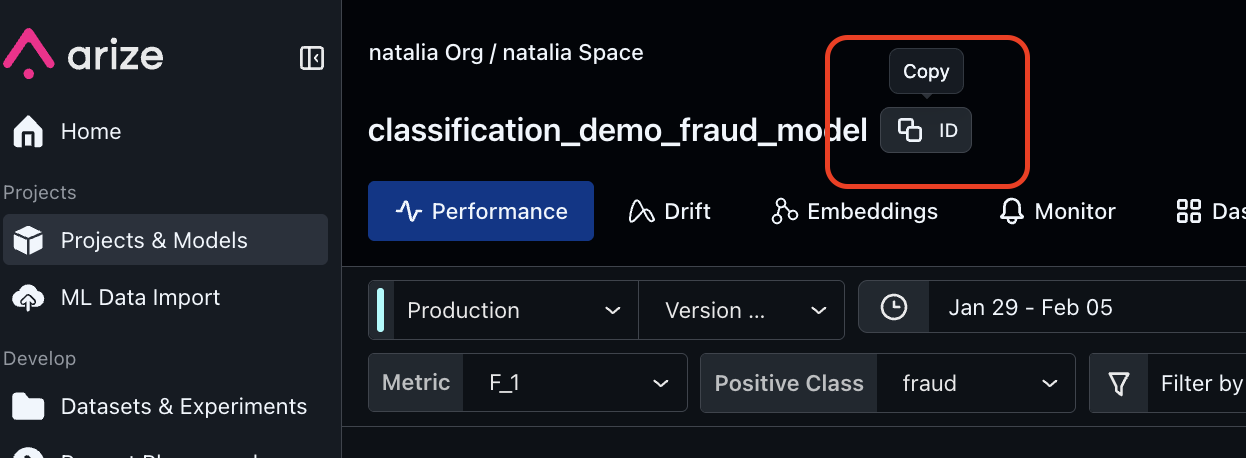

### Set up your variables

In [ ]:
ARIZE_MODEL_ID = "TW9kZWw6MzgxODMxOTczODpZYkw4"
FEATURE_NAME = "dti"
BINNING = "discrete"

In [12]:
variables = {
  "modelId": ARIZE_MODEL_ID,
  "dimensionName": FEATURE_NAME,
  "binningOption": BINNING
  }


## Execute the GraphQL request

In [13]:
result = client.execute(update_binning_for_feature, variables)
result

{'updateDimensionConfig': {'dimensionConfig': {'id': 'RGltZW5zaW9uQ29uZmlnOjExODU6V1kyNA==',
   'modelId': '3818319738',
   'dimensionName': 'dti',
   'dimensionCategory': 'featureLabel',
   'binOption': 'discreteBins',
   'numBins': None,
   'bins': None},
  'model': {'id': 'TW9kZWw6MzgxODMxOTczODpZYkw4',
   'name': 'classification_demo_fraud_model'}}}

## Inspect the feature in Arize

The binning method displayed in the feature details view should match the settings from the request.

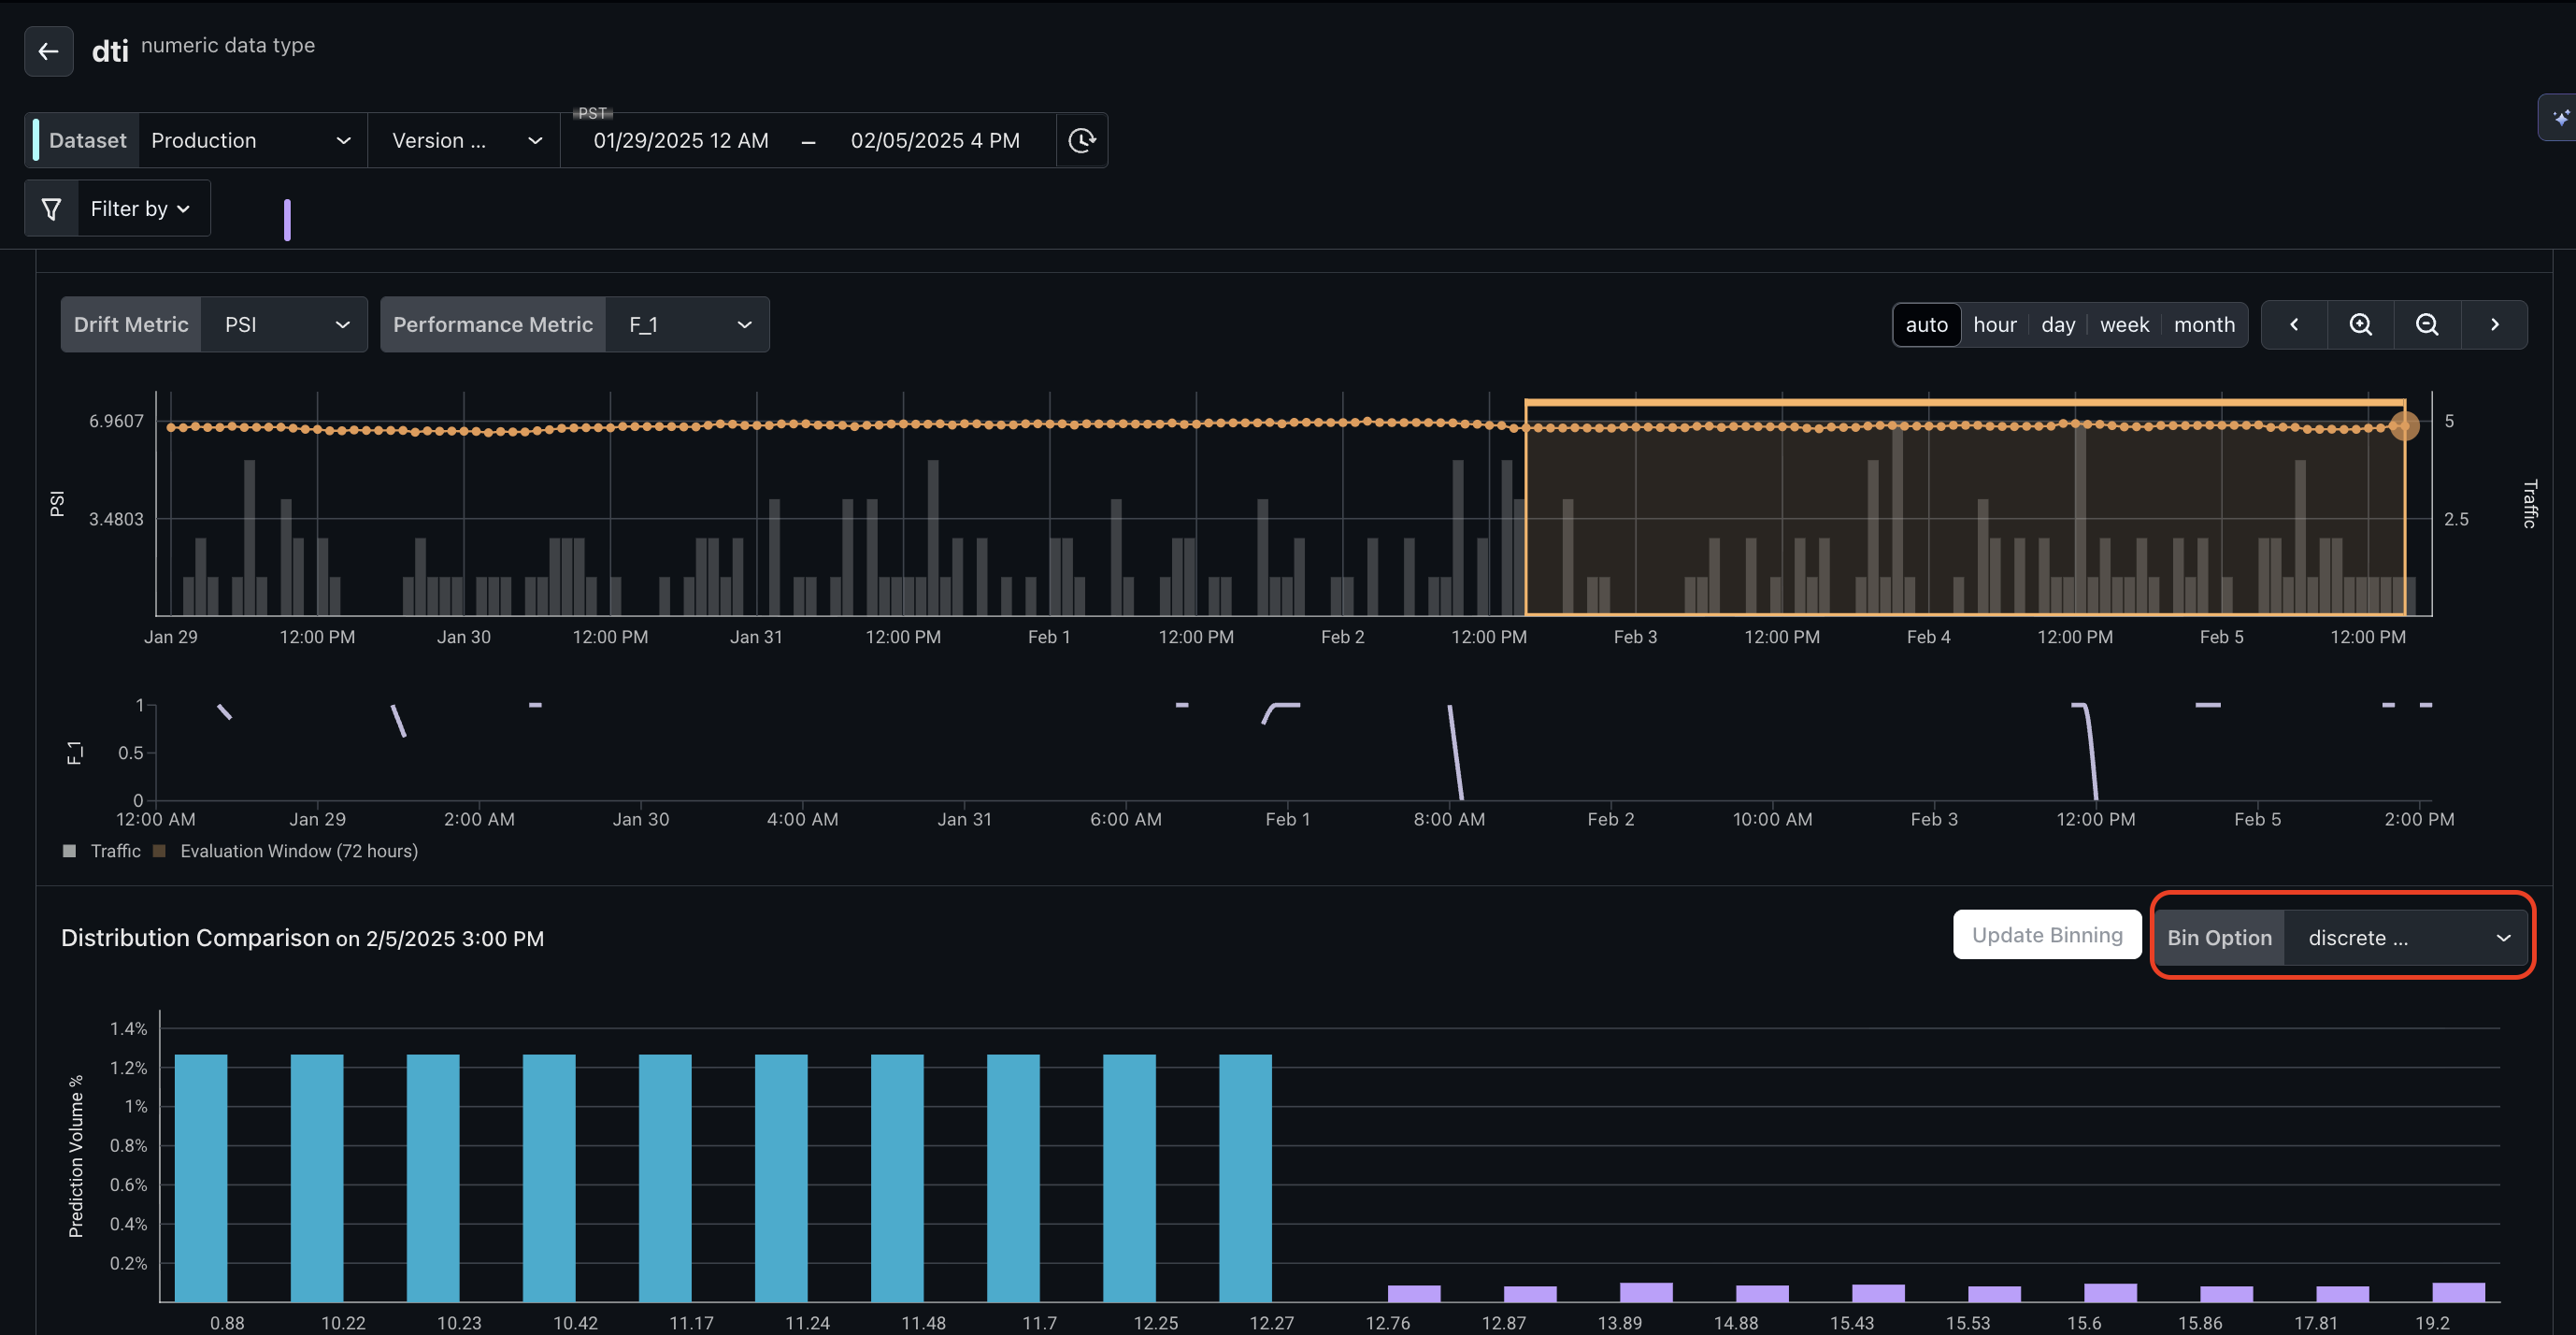